In [2]:
import numpy as np

In [4]:
def diffEqs(rbar, y):
    xf = y[0]
    Mbar = y[1]
    dxf_drbar = -(5.0/3.0) * (Mbar/rbar**2) * (np.sqrt(1.0 + xf**2)/xf)
    dMbar_drbar = 3 * rbar**2 * xf**3
    return [dxf_drbar, dMbar_drbar]
x = diffEqs(0.5, [2, 0.3])
x

[np.float64(-2.23606797749979), 6.0]

done


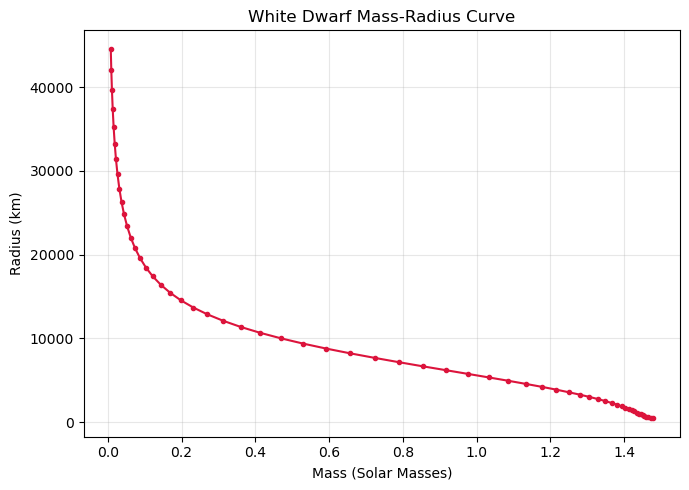

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
def collapsedStar(xfC, drbar = 0.0005, r_start = 0.0005, step_count = 0):
    R_0 = 8623.0
    M_0 = 2.650
    rbar = r_start
    xf = xfC
    Mbar = xfC**3 * rbar**3
    while xf > 0 and step_count < 200000:
        dxf_drbar, dMbar_drbar = diffEqs(rbar, [xf, Mbar])
        xf = xf + dxf_drbar * drbar
        Mbar = Mbar + dMbar_drbar * drbar
        rbar = rbar + drbar
        step_count += 1
    return rbar * R_0, Mbar * M_0
xfC_list = np.logspace(np.log10(0.05), np.log10(50), 60)
radii = []
solar_masses = []
for xfC in xfC_list:
    R, M = collapsedStar(xfC)
    radii.append(R)
    solar_masses.append(M)
plt.figure(figsize=(7, 5))
plt.plot(solar_masses, radii, 'o-', color = 'crimson', markersize = 3)
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Radius (km)')
plt.title('White Dwarf Mass-Radius Curve')
plt.grid(alpha = 0.3)
plt.tight_layout()
print("done")

In [ ]:
def collapsedStar(xfC, drbar = 0.0005, r_start = 0.0005, step_count = 0):
    